In [211]:
import warnings

In [212]:
warnings.filterwarnings("ignore")

In [213]:
import pandas as pd

In [214]:
import numpy as np

In [215]:
from sklearn.datasets import load_iris

In [216]:
from sklearn.preprocessing import StandardScaler

In [217]:
raw_iris = load_iris()

In [218]:
features = raw_iris.feature_names

In [219]:
X_raw = raw_iris.data

In [220]:
y_true = raw_iris.target

In [221]:
scaler = StandardScaler()

In [222]:
X_scaled = scaler.fit_transform(X_raw)

In [223]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)

In [224]:
iris_df['species_id'] = y_true

In [225]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}

In [226]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)

In [227]:
print("Standardized dataset dimensions:", X_scaled.shape)

Standardized dataset dimensions: (150, 4)


In [228]:
print("\nFirst 3 rows of standardized dataset:")


First 3 rows of standardized dataset:


In [229]:
print(iris_df.head(3))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [230]:
cov_matrix = np.cov(X_scaled.T)

In [231]:
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [232]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [233]:
print("\nEigenvalues (Variance components):\n", eigenvalues)


Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [234]:
print("\nEigenvectors (Principal Axes):\n", eigenvectors)



Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [235]:
from sklearn.decomposition import PCA

In [236]:
pca_model = PCA(n_components=2, random_state=42)

In [237]:
X_pca = pca_model.fit_transform(X_scaled)

In [238]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])

In [239]:
pca_df['species_name'] = iris_df['species_name']

In [240]:
print("Transformed PCA space dimensions:", X_pca.shape)

Transformed PCA space dimensions: (150, 2)


In [241]:
print("\nFirst 3 projected coordinates:")


First 3 projected coordinates:


In [242]:
print(pca_df.head(3))

       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


In [243]:
import matplotlib.pyplot as plt

In [244]:
import seaborn as sns

In [245]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='PC_1', ylabel='PC2'>

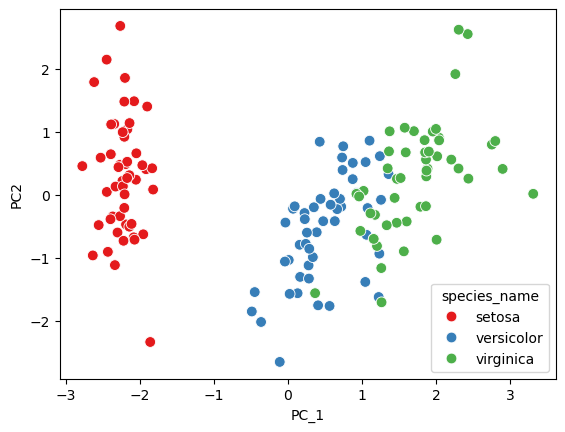

In [246]:
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)

Text(0.5, 1.0, '2-Component PCA Projection of Iris Dataset')

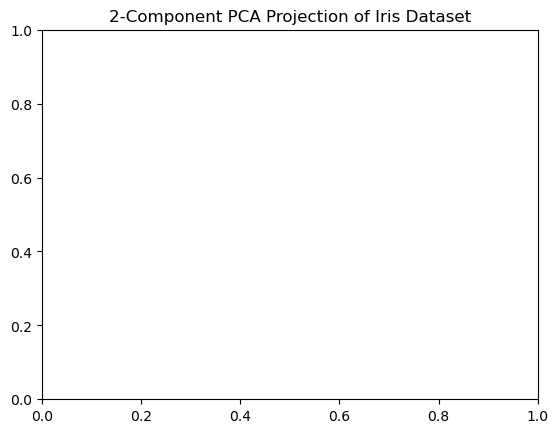

In [247]:
plt.title("2-Component PCA Projection of Iris Dataset")

Text(0.5, 0, 'Principal Component 1 (PC1)')

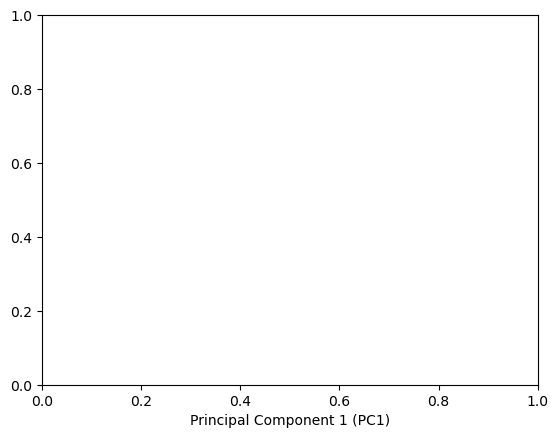

In [248]:
plt.xlabel("Principal Component 1 (PC1)")

Text(0, 0.5, 'Principal Component 2 (PC2)')

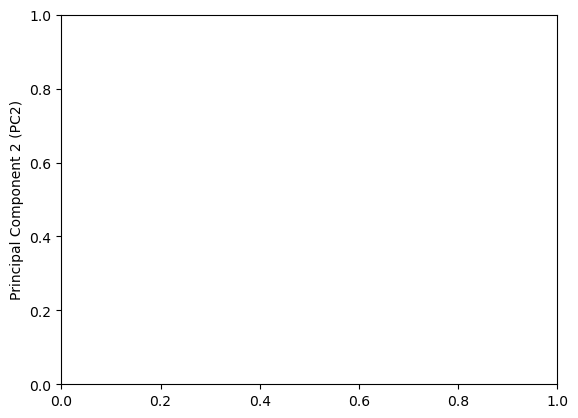

In [249]:
plt.ylabel("Principal Component 2 (PC2)")

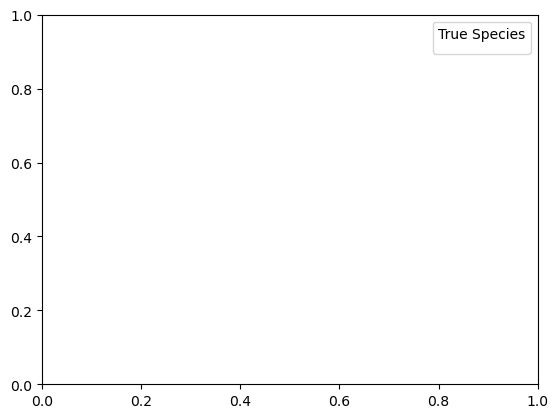

In [250]:
plt.legend(title='True Species')

In [251]:
plt.show()

In [252]:
explained_variance = pca_model.explained_variance_ratio_

In [253]:
cumulative_variance = np.sum(explained_variance)

In [254]:
print("Explained Variance per Component:")
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

Explained Variance per Component:
  PC1: 72.96%
  PC2: 22.85%


In [255]:
print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


Total Cumulative Variance Retained by 2 Components: 95.81%


In [256]:
# ============================================================
# Classification with and without PCA
# Dataset: Iris Dataset
# Classifier: Logistic Regression
# ============================================================

In [257]:
import numpy as np

In [258]:
import pandas as pd

In [259]:
import matplotlib.pyplot as plt

In [260]:
from sklearn.datasets import load_iris

In [261]:
from sklearn.model_selection import train_test_split

In [262]:
from sklearn.preprocessing import StandardScaler

In [263]:
from sklearn.decomposition import PCA

In [264]:
from sklearn.linear_model import LogisticRegression

In [265]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [266]:
iris = load_iris()

In [267]:
X = iris.data  

In [268]:
y = iris.target  

In [269]:
feature_names = iris.feature_names

In [270]:
target_names = iris.target_names

In [271]:
print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [272]:
print("Features:", feature_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [273]:
print("Classes:", target_names)

Classes: ['setosa' 'versicolor' 'virginica']


In [274]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [275]:
scaler = StandardScaler()

In [276]:
X_train_scaled = scaler.fit_transform(X_train)

In [277]:
X_test_scaled = scaler.transform(X_test)

In [278]:
print("\n========================================")
print("CLASSIFICATION WITHOUT PCA")
print("========================================")


CLASSIFICATION WITHOUT PCA


In [279]:
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [280]:
model_without_pca.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [281]:
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)

In [282]:
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

In [283]:
print("Accuracy without PCA:",
      accuracy_without_pca)

Accuracy without PCA: 0.9333333333333333


In [284]:
print("\nClassification Report:")


Classification Report:


In [285]:
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [286]:
# ============================================================
# PART B: CLASSIFICATION WITH PCA
# ============================================================

In [287]:
print("\n========================================")
print("CLASSIFICATION WITH PCA")
print("========================================")



CLASSIFICATION WITH PCA


In [288]:
pca = PCA(
    n_components=2
)

In [289]:
X_train_pca = pca.fit_transform(
    X_train_scaled
)

In [290]:
X_test_pca = pca.transform(
    X_test_scaled
)

In [291]:
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)

Explained Variance Ratio: [0.72677234 0.23066667]


In [292]:
print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

Total Explained Variance: 0.9574390106545365


In [293]:
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [294]:
model_with_pca.fit(
    X_train_pca,
    y_train
)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [295]:
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)


In [296]:
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

In [297]:
print("Accuracy with PCA:",
      accuracy_with_pca)

Accuracy with PCA: 0.9


In [298]:
print("\nClassification Report:")


Classification Report:


In [299]:
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [300]:
# ============================================================
# PART C: COMPARE BOTH MODELS
# ============================================================

In [301]:
print("\n========================================")
print("COMPARISON")
print("========================================")



COMPARISON


In [302]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

In [303]:
print(comparison)

        Method  Number of Features  Accuracy
0  Without PCA                   4  0.933333
1     With PCA                   2  0.900000


In [304]:
# ============================================================
# PART D: VISUALIZE PCA FEATURES
# ============================================================

In [305]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

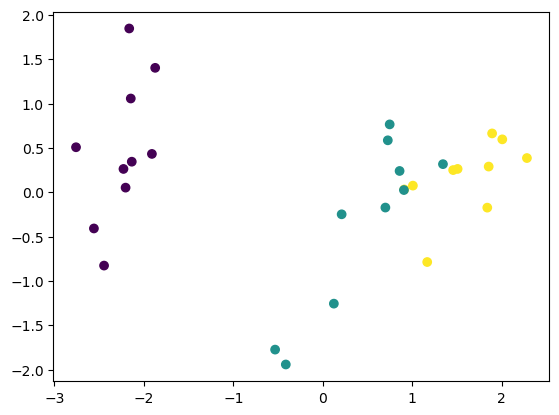

In [306]:
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

Text(0.5, 0, 'Principal Component 1')

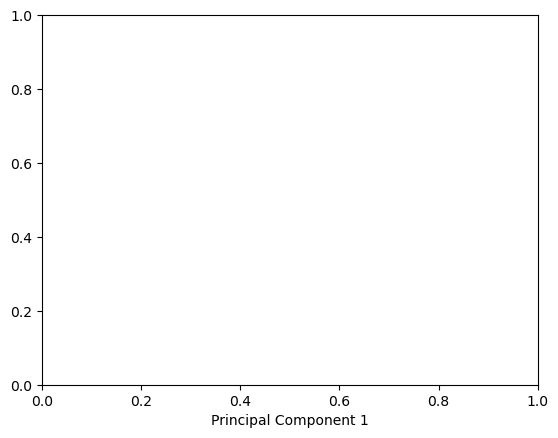

In [307]:
plt.xlabel("Principal Component 1")

Text(0, 0.5, 'Principal Component 2')

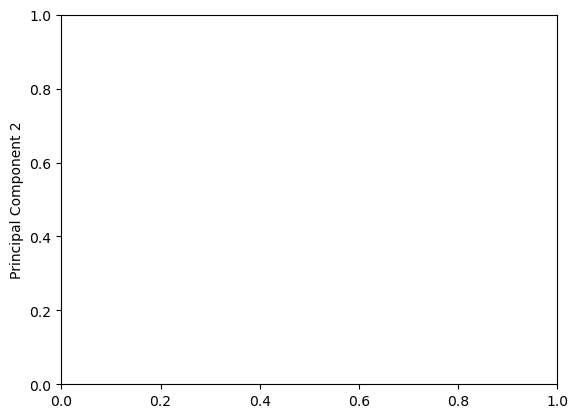

In [308]:
plt.ylabel("Principal Component 2")

Text(0.5, 1.0, 'Iris Classification Using PCA')

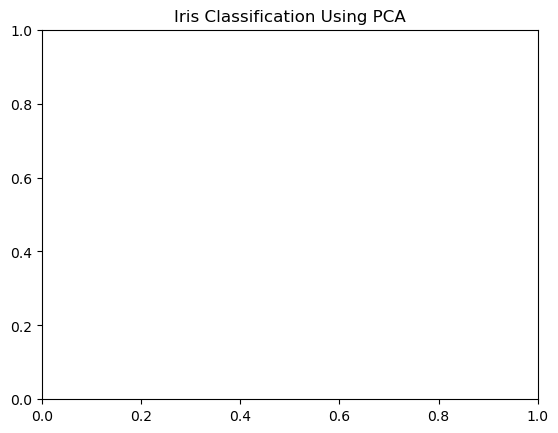

In [309]:
plt.title("Iris Classification Using PCA")

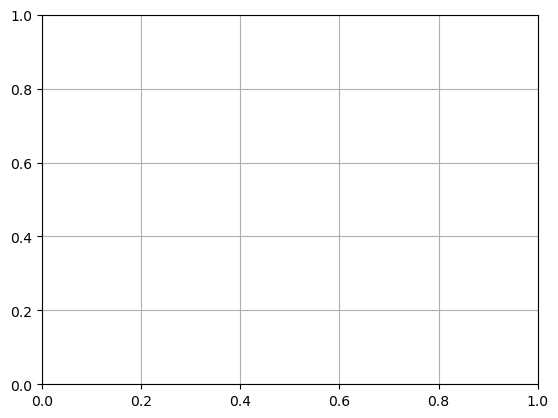

In [310]:
plt.grid()

In [311]:
plt.show()

## TASK-2

In [312]:
import warnings

In [313]:
warnings.filterwarnings("ignore")

In [314]:
from sklearn.cluster import KMeans

In [315]:
import matplotlib.pyplot as plt

In [316]:
wcss = []

In [317]:
k_range = range(1, 11)

In [318]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [319]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

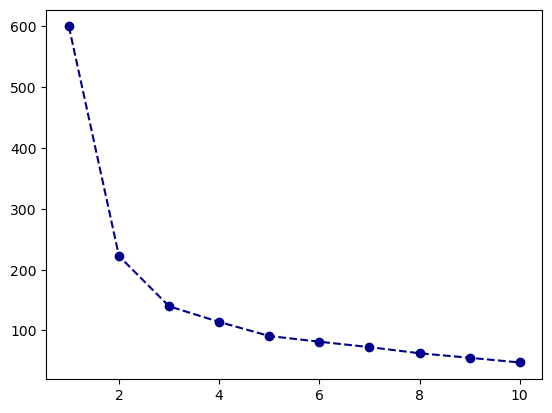

In [320]:
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')

Text(0.5, 1.0, 'Elbow Method: Within-Cluster Sum of Squares (WCSS)')

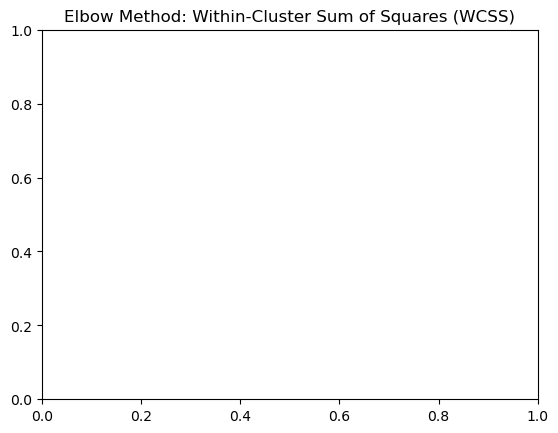

In [321]:
plt.title("Elbow Method: Within-Cluster Sum of Squares (WCSS)")

Text(0.5, 0, 'Number of Clusters (k)')

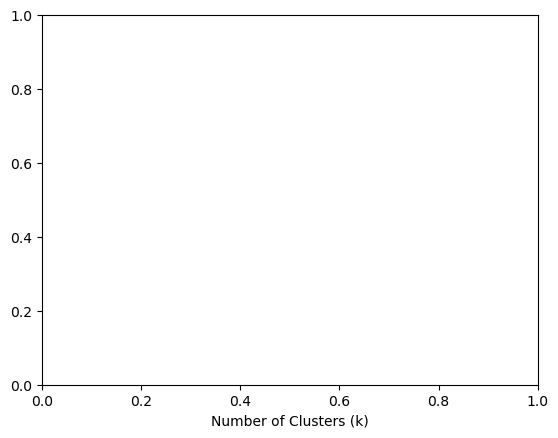

In [322]:
plt.xlabel("Number of Clusters (k)")

Text(0, 0.5, 'WCSS (Inertia)')

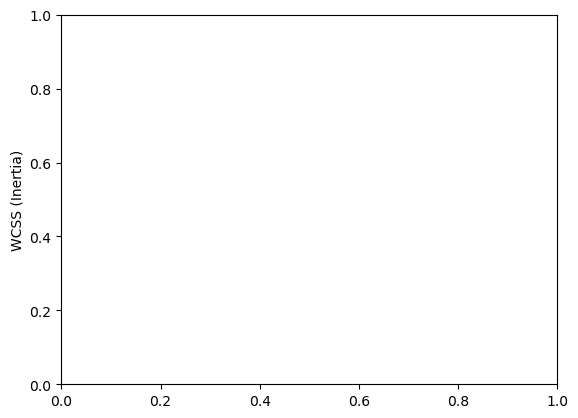

In [323]:
plt.ylabel("WCSS (Inertia)")

([<matplotlib.axis.XTick at 0x1b48c5b4e10>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

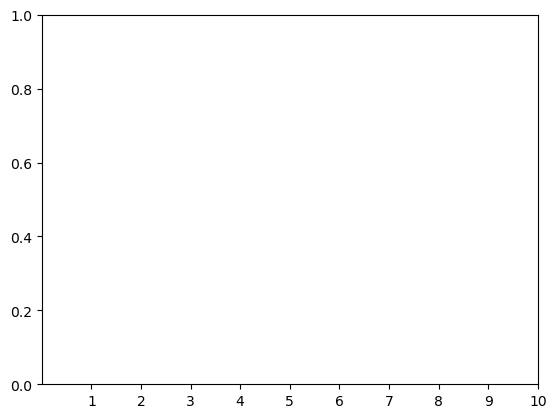

In [324]:
plt.xticks(k_range)

In [325]:
plt.show()

In [326]:
from sklearn.metrics import silhouette_score

In [327]:
silhouette_scores = []

In [328]:
k_eval = range(2, 6)

In [329]:
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

In [330]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Axes: >

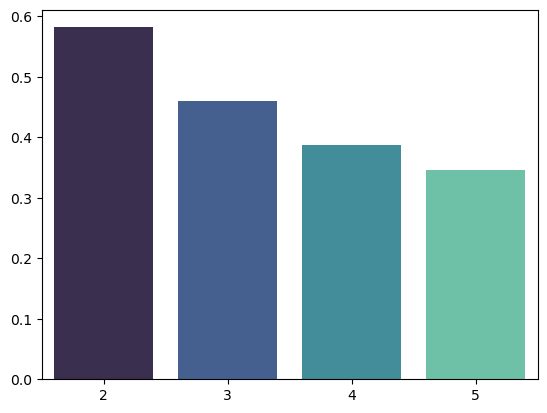

In [331]:
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')

Text(0.5, 1.0, 'Silhouette Analysis for Optimal k')

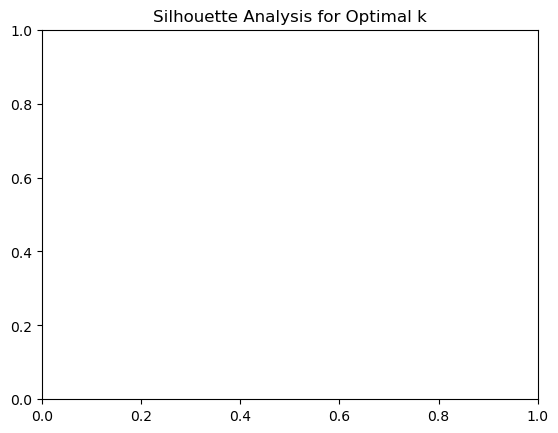

In [332]:
plt.title("Silhouette Analysis for Optimal k")

Text(0.5, 0, 'Number of Clusters (k)')

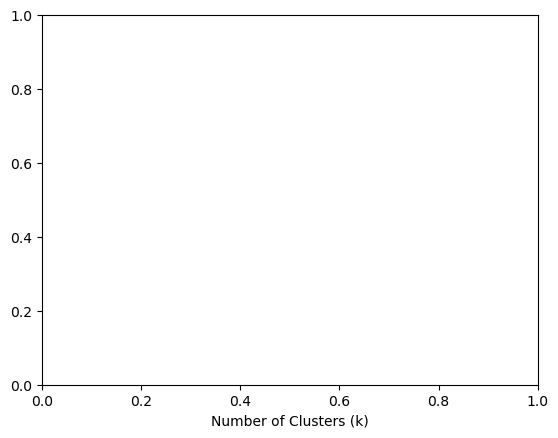

In [333]:
plt.xlabel("Number of Clusters (k)")

Text(0, 0.5, 'Average Silhouette Coefficient')

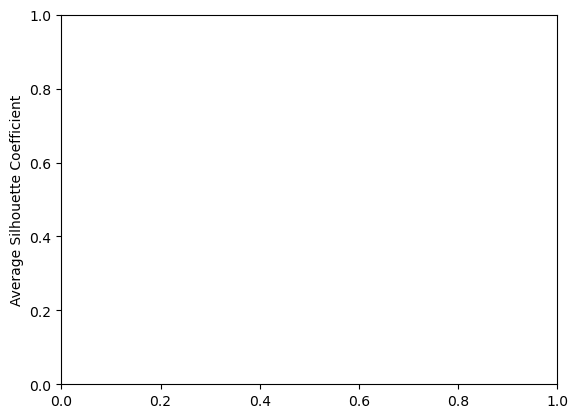

In [334]:
plt.ylabel("Average Silhouette Coefficient")

In [335]:
plt.show()

In [336]:
best_k = k_eval[np.argmax(silhouette_scores)]

In [337]:
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")

k = 2 yielded the highest silhouette coefficient (0.5818).


In [338]:
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

In [339]:
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)

In [340]:
iris_df['cluster_raw'] = kmeans_raw_labels

In [341]:
print("K-Means clustering complete. First 5 sample allocations:")

K-Means clustering complete. First 5 sample allocations:


In [342]:
print(iris_df[['species_name', 'cluster_raw']].head(5))

  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


In [343]:
raw_centroids_scaled = kmeans_raw.cluster_centers_

In [344]:
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

In [345]:
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)
centroids_df.index = [f"Cluster_{i}" for i in range(3)]

In [346]:
print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")

--- Estimated Cluster Centroids (Original Physical Units - cm) ---


In [347]:
print(centroids_df)

           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster_0           5.799612          2.653772           4.382414   
Cluster_1           4.992043          3.429444           1.471740   
Cluster_2           6.792945          3.087827           5.524364   

           petal width (cm)  
Cluster_0          1.418814  
Cluster_1          0.251935  
Cluster_2          1.977790  


In [348]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [349]:
raw_data = scaler.inverse_transform(X_scaled)

<Axes: >

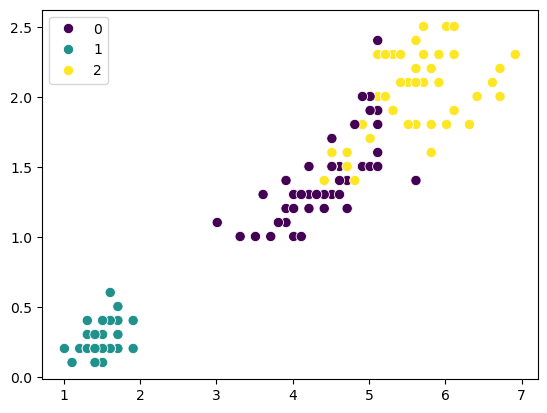

In [350]:
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')

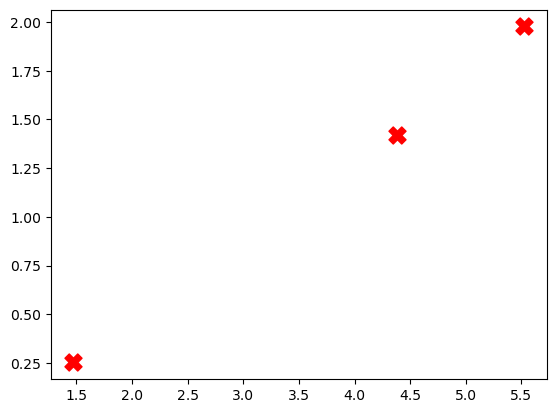

In [351]:
plt.scatter(
    raw_centroids_physical[:, 2], 
    raw_centroids_physical[:, 3], 
    color='red', 
    marker='X', 
    s=150, 
    label='Centroids'
)

Text(0.5, 1.0, 'K-Means Clustering: Petal Width vs. Petal Length')

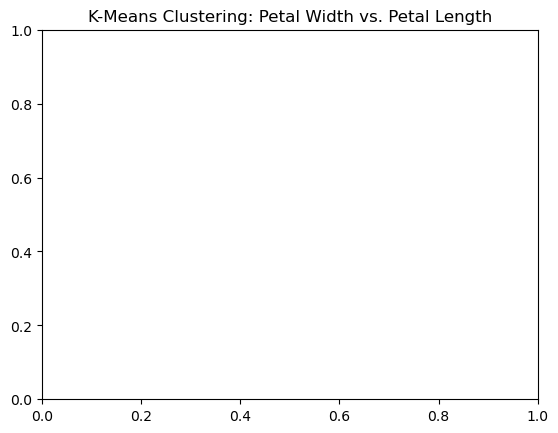

In [352]:
plt.title("K-Means Clustering: Petal Width vs. Petal Length")

Text(0.5, 0, 'Petal Length (cm)')

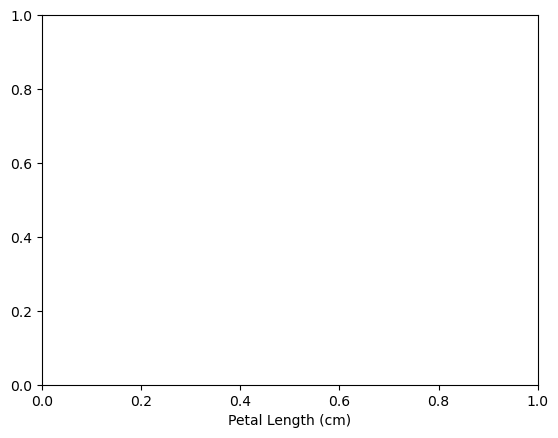

In [353]:
plt.xlabel("Petal Length (cm)")

Text(0, 0.5, 'Petal Width (cm)')

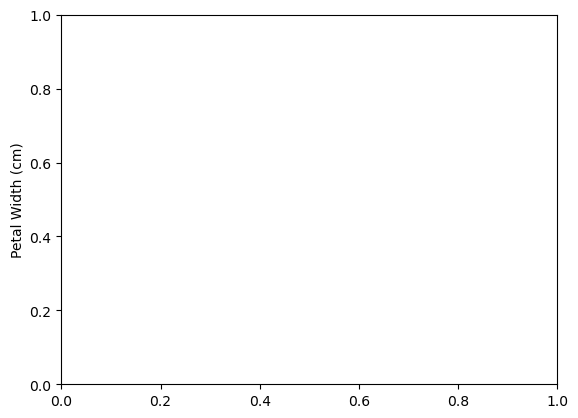

In [354]:
plt.ylabel("Petal Width (cm)")

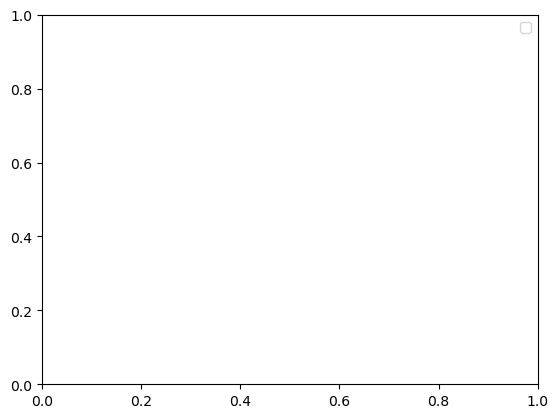

In [355]:
plt.legend()

In [356]:
plt.show()

## TASK-3

In [357]:
import warnings

In [358]:
warnings.filterwarnings("ignore")

In [359]:
from sklearn.cluster import KMeans

In [360]:
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

In [361]:
iris_df['cluster_pca'] = kmeans_pca_labels

In [362]:
print("PCA space K-Means clustering completed successfully.")

PCA space K-Means clustering completed successfully.


In [363]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [364]:
sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)

In [365]:
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)

In [366]:
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)

In [367]:
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)

In [368]:
print("--- Internal Validation (Unsupervised Quality Metrics) ---")

--- Internal Validation (Unsupervised Quality Metrics) ---


In [369]:
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")

Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90


In [370]:
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")


PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


In [371]:
import matplotlib.pyplot as plt

In [372]:
import seaborn as sns

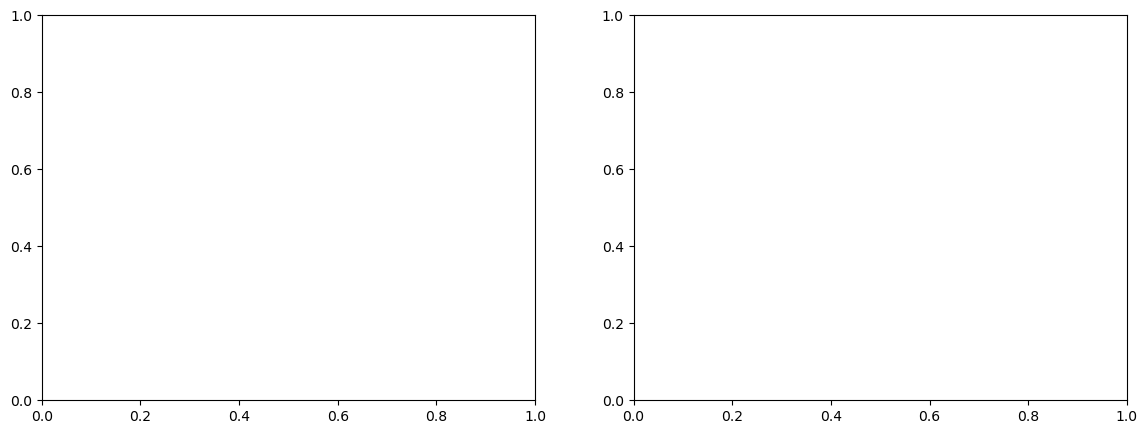

In [373]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [374]:
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels, 
    palette='viridis', s=60, ax=axes[0]
)

<Axes: xlabel='PC_1', ylabel='PC2'>

In [375]:
axes[0].set_title("K-Means Cluster Assignments (PCA Space)")

Text(0.5, 1.0, 'K-Means Cluster Assignments (PCA Space)')

In [376]:
axes[0].set_xlabel("PC1")

Text(0.5, 4.444444444444445, 'PC1')

In [377]:
axes[0].set_ylabel("PC2")

Text(4.444444444444452, 0.5, 'PC2')

In [378]:
axes[0].legend(title='Assigned Cluster')

In [379]:
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name', 
    palette='Set1', s=60, ax=axes[1]
)

<Axes: xlabel='PC_1', ylabel='PC2'>

In [380]:
axes[1].set_title("True Taxonomic Species Labels")

Text(0.5, 1.0, 'True Taxonomic Species Labels')

In [381]:
axes[1].set_xlabel("PC1")

Text(0.5, 4.444444444444445, 'PC1')

In [382]:
axes[1].set_ylabel("PC2")

Text(596.2626262626262, 0.5, 'PC2')

In [383]:
axes[1].legend(title='True Species')

In [384]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [385]:
plt.show()

## POSTLAB

First 5 rows:
   PassengerId  Survived  Pclass            Name     Sex  Age  SibSp  Parch  \
0            1         0       3      John Smith    male   22      1      0   
1            2         1       1    Mary Johnson  female   38      1      0   
2            3         1       3     David Brown    male   26      0      0   
3            4         1       1     Emily Davis  female   35      1      0   
4            5         0       3  Michael Wilson    male   35      0      0   

   Ticket   Fare Cabin Embarked  
0  A12345   7.25   NaN        S  
1  B23456  71.28   C85        C  
2  C34567   7.92   NaN        S  
3  D45678  53.10  C123        S  
4  E56789   8.05   NaN        S  

Scaled Data:
[[-0.4487118  -0.88297518  0.33333333 -0.46852129]
 [ 0.747853    1.97675677  0.33333333 -0.46852129]
 [-0.1495706  -0.85305139 -0.77777778 -0.46852129]
 [ 0.5234971   1.16479477  0.33333333 -0.46852129]
 [ 0.5234971  -0.84724528 -0.77777778 -0.46852129]]

Explained Variance Ratio:
[0.4860773

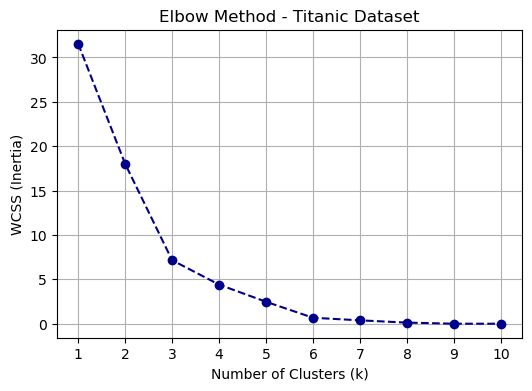


Clustered Data:
        PC1       PC2  Cluster
0 -0.595529 -0.240377        1
1  1.272790  1.669795        0
2  0.152615 -0.972620        1
3  0.820348  1.118097        0
4  0.609929 -1.023056        1


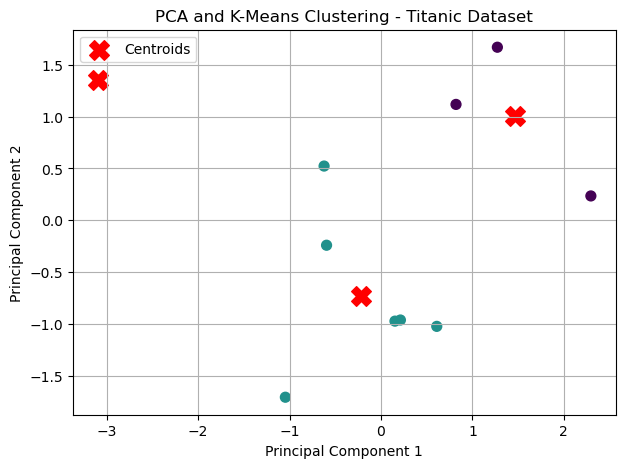

In [388]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load Titanic Dataset
df = pd.read_csv("titanic-Dataset.csv")

# Display dataset
print("First 5 rows:")
print(df.head())

# Select numerical features
X = df[['Age', 'Fare', 'SibSp', 'Parch']]

# Handle missing values
X = X.copy()
X['Age'] = X['Age'].fillna(X['Age'].median())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Data:")
print(X_scaled[:5])

# ---------------- PCA ----------------

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(sum(pca.explained_variance_ratio_))

# PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("\nPCA Data:")
print(pca_df.head())

# ---------------- ELBOW METHOD ----------------

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(
    k_range,
    wcss,
    marker='o',
    linestyle='--',
    color='darkblue'
)

plt.title("Elbow Method - Titanic Dataset")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.grid(True)
plt.show()

# ---------------- K-MEANS CLUSTERING ----------------

# Choose number of clusters
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

# Add cluster labels
pca_df['Cluster'] = clusters

print("\nClustered Data:")
print(pca_df.head())

# ---------------- CLUSTER VISUALIZATION ----------------

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    s=50
)

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200,
    color='red',
    label='Centroids'
)

plt.title("PCA and K-Means Clustering - Titanic Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()